
## Academic Integrity and Learning Statement

By submitting my work, I confirm that:

- The code, analysis, and documentation in this notebook are my own work and reflect my own understanding.
- I am prepared to explain all code and analysis included in this submission.

If I used assistance (e.g., AI tools, tutors, or other resources), I have:

- Clearly documented where and how external tools or resources were used in my solution.
- Included a copy of the interaction (e.g., AI conversation or tutoring notes) in an appendix.

I acknowledge that:

- I may be asked to explain any part of my code or analysis during evaluation.
- Misrepresenting assisted work as my own constitutes academic dishonesty and undermines my learning.


## Task F: correlation analysis

- quantify the linear relationship between the energy_per_hundred and the per_hundred columns by analysing their correlation with each other
- Reveal the true nature of the relationship (linear or non-linear) between variables using visualizations. Based on the correlation coefficients you found in the previous task, pick the three most correlated and the three least correlated nutrients with the energy_per_hundred column. Plot them using scatter plots. Comment on the relationship
- Test the independence of two categorical variables statistically. Use the energy_per_hundred column to create a new variable that holds equal proportion of values in three categories (low, medium and high energy). Test if the energy level is associated with the country in which the product is produced

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [18]:
df = pd.read_csv("data_clean.csv")

In [19]:
# define the per_hundred columns
col_hundred = df.filter(regex="_per_hundred$").columns

# calculate the correlation coefficient between the energy_per_hundred column and the other _per_hundred columns
correlation = df[col_hundred].corr()["energy_per_hundred"]

# remove the energy_kcal_per_hundred and energy_per_hundred correlation coefficients that are equal to 1
correlation = correlation.drop(["energy_kcal_per_hundred", "energy_per_hundred"])

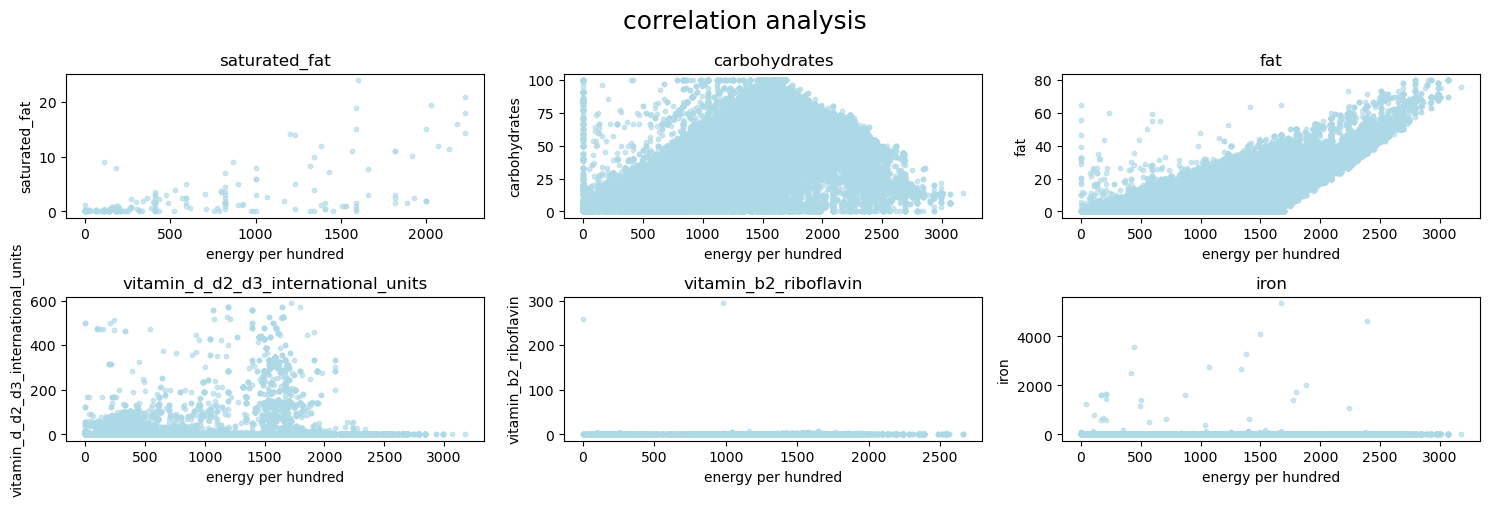

In [20]:
# based on the correlation coefficients, plot the three most highly correlated and the three less correlated variables using scatter plots

top_3_corr = abs(correlation).sort_values().tail(3).index
low_3_corr = abs(correlation).sort_values().head(3).index
corr_plot = top_3_corr.append(low_3_corr)

fig, axes = plt.subplots(2, 3, figsize=(15,5))
axes = axes.flatten()

for ax, name in zip(axes, corr_plot):
    ax.scatter(x=df["energy_per_hundred"], y=df[name], s=10, alpha=0.6, color="lightblue")
    ax.set_title(name.replace("_per_hundred", ""))
    ax.set_xlabel("energy per hundred")
    ax.set_ylabel(name.replace("_per_hundred", ""))

plt.suptitle("correlation analysis", fontsize=18)
plt.tight_layout()

#### Comments on the graph

It looks like there is a linear relationship between fat (both fat and saturated fat) contents and energy. Interestingly, the relationship between carbohydrates and energy is not linear (it first goes up, then down). This makes sense, as other nutrients (fat) contain more energy per hundred grams than carbohydrates. Thus 100g of fat will contain 0g of carbohydrates but will have more energy than 100g of only carbs. For the vitamins and iron, there is no correlation with energy, which is to be expected.

In [30]:
# Test the independence of two categorical variables statistically. 
# Use the energy_per_hundred column to create a new variable that holds equal proportion of values in three categories (low, medium and high energy). 
# Test if the energy level is associated with the country in which the product is produced

# Create a clean dataset for the test
df_test = df[df["energy_category"].notna() & df["country"].notna()]

# split the data into three categories
df_test["energy_category"] = pd.qcut(df_test["energy_per_hundred"], q=3, labels=["low", "medium", "high"], duplicates='drop')

/tmp/ipykernel_131094/2892975035.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_test["energy_category"] = pd.qcut(df_test["energy_per_hundred"], q=3, labels=["low", "medium", "high"], duplicates='drop')


0

In [32]:
# Check if categories were well assigned
print(df_test["energy_category"].value_counts())
print(df_test["energy_category"].isna().sum())

medium    66478
low       63219
high      58461
Name: energy_category, dtype: int64
0


In [37]:
# test if there is an association between the two variables using a chi square test
import scipy.stats as stats
# first look at the contingency table
print(pd.crosstab(df_test.energy_category, df_test.country))

# test for independence
chi_square, p_value, dof, matrix = stats.chi2_contingency(pd.crosstab(df_test.energy_category, df_test.country))

print("p_value:", p_value)

country           CH  DE  IT     US
energy_category                    
low              129   3   2  63085
medium            71   0   1  66406
high              40   0   0  58421
p_value: 4.2562305091623815e-10


#### Comments

We can reject the null hypothesis, the two variables are not independent. When looking at the data, we observe that the distribution of low, medium and high caloric food is not the same in CH than in the US for instance